In [5]:
import pandas as pd
df = pd.read_csv("insurance_data.csv")
df.head()

,age,has_insurance
0,18,0
1,19,0
2,20,0
3,22,0
4,23,0


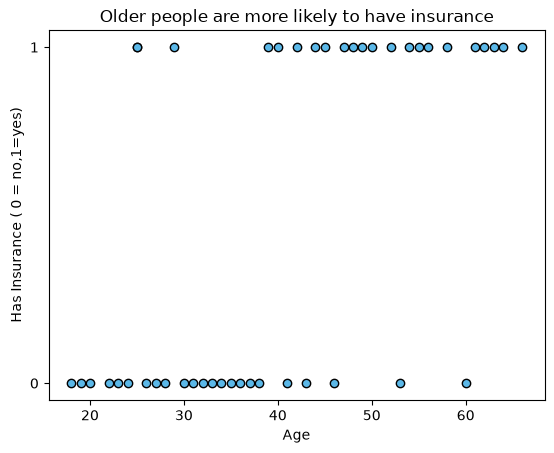

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df.age,df.has_insurance,color='#5BB8E8',edgecolor='k')
plt.xlabel("Age")
plt.ylabel("Has Insurance ( 0 = no,1=yes)")
plt.title("Older people are more likely to have insurance")
plt.yticks([0,1])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X = df[['age']]
y = df['has_insurance']

x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((36, 1), (9, 1))

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
ages = pd.DataFrame({'age':[22,45,60,99]})
model.predict(ages)

array([0, 1, 1, 1])

In [19]:
model.predict_proba(ages)

array([[8.91095007e-01, 1.08904993e-01],
       [3.31170032e-01, 6.68829968e-01],
       [7.36339674e-02, 9.26366033e-01],
       [6.83054789e-04, 9.99316945e-01]])

In [21]:
model.coef_,model.intercept_

(array([[0.121951]]), array([-4.78489728]))

In [25]:
import math

def sigmoid(x):
    return 1/(1 + math.exp(-x))

def prediction_function(age):
    z = model.coef_[0][0] * age + model.intercept_[0]
    y = sigmoid(z)
    return y

In [26]:
prediction_function(22)

0.10890499280794343

In [27]:
model.score(x_test,y_test)

0.7777777777777778

In [29]:
model.score(x_train,y_train)

0.8055555555555556

In [30]:
model.predict(x_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 0])

In [31]:
y_test

39    0
25    0
26    1
43    1
35    1
41    1
4     0
12    0
8     0
Name: has_insurance, dtype: int64

In [32]:
7/9

0.7777777777777778

In [35]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9



In [36]:
y_test.to_list(),y_pred

([0, 0, 1, 1, 1, 1, 0, 0, 0], array([1, 1, 1, 1, 1, 1, 0, 0, 0]))

In [42]:
# precision for 0 --> 1 
# In recall always starts with truth  for 0--> 3/5
# In Precision always starts with pred
# f1 score = 2 * precision*recall/precision + recall
1/1,3/5,4/6, 2 * (1*0.60/1+0.60)

(1.0, 0.6, 0.6666666666666666, 2.4)

In [43]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
cm

array([[3, 2],
       [0, 4]])

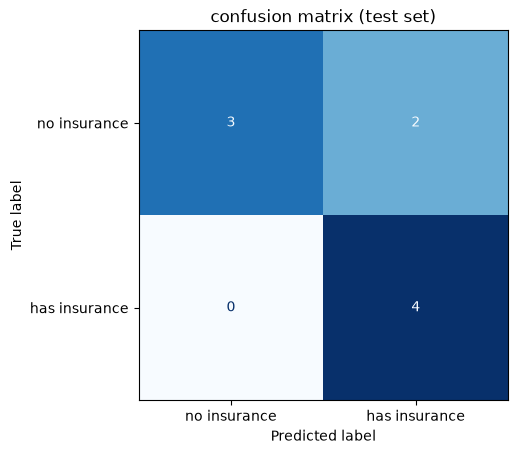

In [45]:
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=['no insurance','has insurance']
)

disp.plot(cmap='Blues',colorbar=False)
plt.title('confusion matrix (test set)')
plt.show()